# Load & Parse Data

In [1]:
import importlib
import utils.parse_data  

importlib.reload(utils.parse_data)

/home/ab126/programs/micromamba/envs/fmri311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils.parse_data' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/parse_data.py'>

In [2]:
from utils.parse_data import parse_dataset
from pathlib import Path

data_path = Path('../data/pooled_stratified_share_vc')
X_train, Y_train, X_test, Y_test, device = parse_dataset(root_dir=data_path, M=50, H=3, normalize=True, stride=1, test_ratio=0.2,
                                                         test_subjects=None, random_state=42, verbose=True)

Using dataset path: ../data/pooled_stratified_share_vc
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2880 runs from 8 subjects
Subjects: ['subjA2s60K-Hhm', 'subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjsRowSC6dc4', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2880
Loading time: 6.90 seconds
Device: cuda
Normalizing dataset...
Building sliding windows...
Splitting by subject...
Train subjects: ['subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjQX6R7rImeb', 'subjxpYwO4azeZ', 'subjtySNgRhV65', 'subjOenz4SHyaO']
Test subjects : ['subjsRowSC6dc4', 'subjA2s60K-Hhm']
Train runs: 2144
Test runs : 736
Final shapes - Train: (373056, 50, 23), (373056, 3, 23) | Test: (128064, 50, 23), (128064, 3, 23)


# Loda Trained Models

In [85]:
import importlib
import utils.validation

importlib.reload(utils.validation)

<module 'utils.validation' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/validation.py'>

In [3]:
import torch
from pathlib import Path

from utils.validation import load_model_from_weights_save
from models.transformer.transformer_api_library import transformer_model_generator

weights_path = Path("saves") / "trained_model_weights" / "transformer_final_vc.pt"
model = load_model_from_weights_save(weights_path)
model.eval()


/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/validation.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(weights_path, map_location="cp

TransformerForecastModel(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=69, bias=True)
)

## Significance Test

In [84]:
import importlib
import utils.training

importlib.reload(utils.training)

<module 'utils.training' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/training.py'>

In [69]:
import importlib
import models.baselines.baseline_models

importlib.reload(models.baselines.baseline_models)

<module 'models.baselines.baseline_models' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/models/baselines/baseline_models.py'>

In [4]:
import numpy as np

from utils.measures import compute_rmse, compute_eta_gauss
from utils.validation import permutation_forecast_test
from utils.training import predict_forecasting_model

from models.baselines.baseline_models import last_value_model_generator, mean_value_model_generator


metric_func = lambda y_true, y_pred: -compute_rmse(y_true, y_pred)

preds_real = predict_forecasting_model(model, X_test, batch_size=32, device=device)
real_score = metric_func(Y_test, preds_real)

model_gen = lambda: last_value_model_generator(H=3)
# model_gen = lambda: mean_value_model_generator(H=3)
null_scores = permutation_forecast_test(model_gen,
    X_train,
    Y_train,
    X_test,
    Y_test,
    n_perm=1000,
    metric_fn=metric_func,
    rng=1234,
    device=device,
)

p = (1 + np.sum(null_scores >= real_score)) / (len(null_scores) + 1)
print(f"p-value: {p:.4f}")

100%|██████████| 1000/1000 [00:48<00:00, 20.42it/s]

p-value: 0.0010


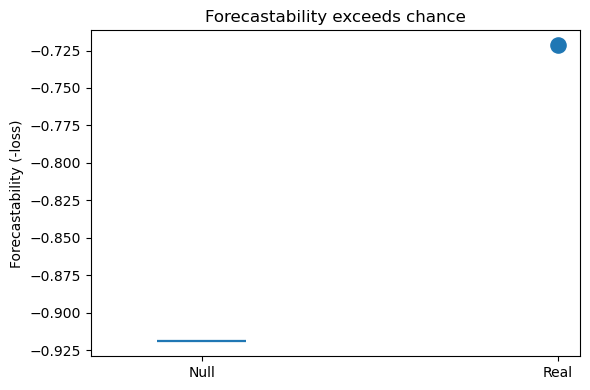

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.violinplot(
    [null_scores],
    positions=[0],
    showmeans=True
)

plt.scatter(
    [1],
    [real_score],
    s=120
)

plt.xticks([0,1], ["Null", "Real"])
plt.ylabel("Forecastability (-loss)")
plt.title("Forecastability exceeds chance")

plt.tight_layout()

# Quick Stats

## Percent Information Explained

In [ ]:
from utils.measures import compute_conditional_entropy_from_log_prob_api

